In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Pro_Solvers.pro_solvers import solve_heat, solve_heat2d, image_diff
from My_Solvers.pde_solvers import fdm, fdm2D, image_diff_an
plt.rcParams["figure.figsize"] = (5, 3)  # width x height in inches
from skimage import data, io
from matplotlib.animation import FuncAnimation
import time
from scipy.interpolate import interp1d
#from manim import *
#from manim.utils.ipython_magic import ManimMagic
#get_ipython().register_magics(ManimMagic)

#%load_ext manim

first part done in 0.04420948028564453 seconds
first part done in 16.251625299453735 seconds


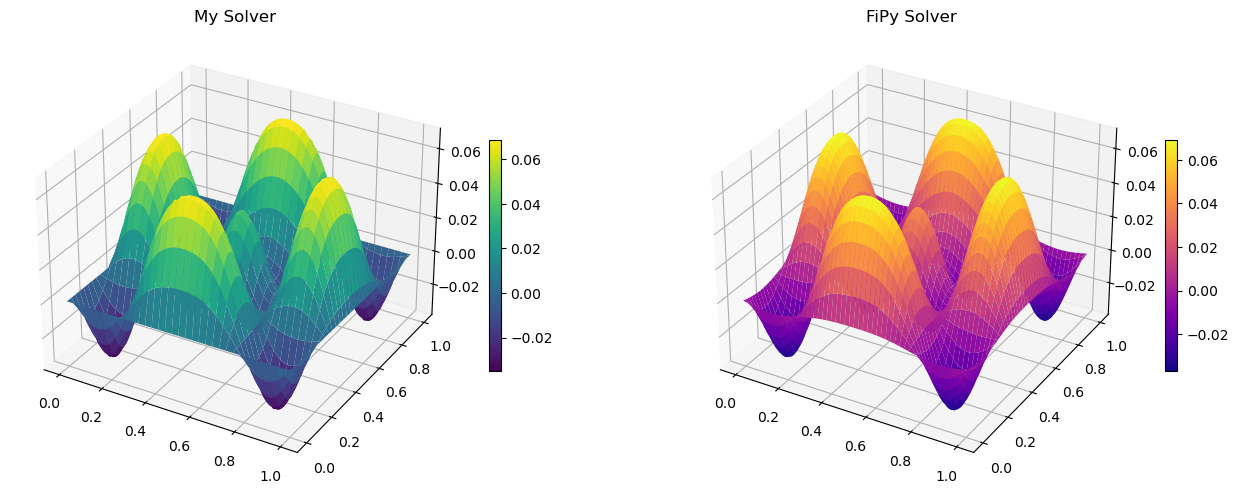

In [8]:
# PDE: u_t = alpha u_xx
alpha = 1.0
Lx = 1.0
Ly = 1.0
dx = 0.01
dy = 0.01
dt = 0.0001
t_end = 0.01  # Try varying this

# Initial condition: sin(3 pi x)
#u0 = lambda x: np.sin(3 * np.pi * x) + 1
#u0 = lambda x: x**2
#u0 = lambda x : np.where(np.sin(100*x) > 0.0, 1.0, 0.0)
#u0 = lambda x: np.where(np.abs(x) < .1, 100.0, 0.0)

N = 100
A = 1#np.random.randint(0,N)
j = 2#np.random.rand(0,N)
k = 6#np.random.rand(0,N)
def u0(x, y):
    return A * np.cos(j * np.pi * x) * np.cos(k * np.pi * y) + np.cos(k * np.pi * x) * np.cos(j * np.pi * y)


def u_exact(x, y, t):
    return A * np.cos(j * np.pi * x) * np.cos(k * np.pi * y) * np.exp(-((k * np.pi)**2 + (j * np.pi)**2) * t)


tick = time.time()
X, Y, U = fdm2D(u0, alpha, dx, dy, t_end, Lx, Ly)
tock = time.time()
ft = tock - tick
print(f"first part done in {ft} seconds")
Xf, Yf, Uf = solve_heat2d(u0, alpha, dx, dy, t_end, Lx, Ly)
tick = time.time()
ft = tock - tick
print(f"first part done in {-ft} seconds")

fig = plt.figure(figsize=(16, 6))

# First plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, U, cmap='viridis', edgecolor='none')
fig.colorbar(surf1, ax=ax1, shrink=0.5)
ax1.set_title('My Solver')

# Second plot
Nx = int(Lx / dx)
Ny = int(Ly / dy)
x = np.linspace(0, Lx, Nx)  # x values from 0 to Lx
y = np.linspace(0, Ly, Ny)  # y values from 0 to Ly
Xf, Yf = np.meshgrid(x, y) 
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(Xf, Yf, Uf, cmap='plasma', edgecolor='none')
fig.colorbar(surf2, ax=ax2, shrink=0.5)
ax2.set_title('FiPy Solver')

plt.show()

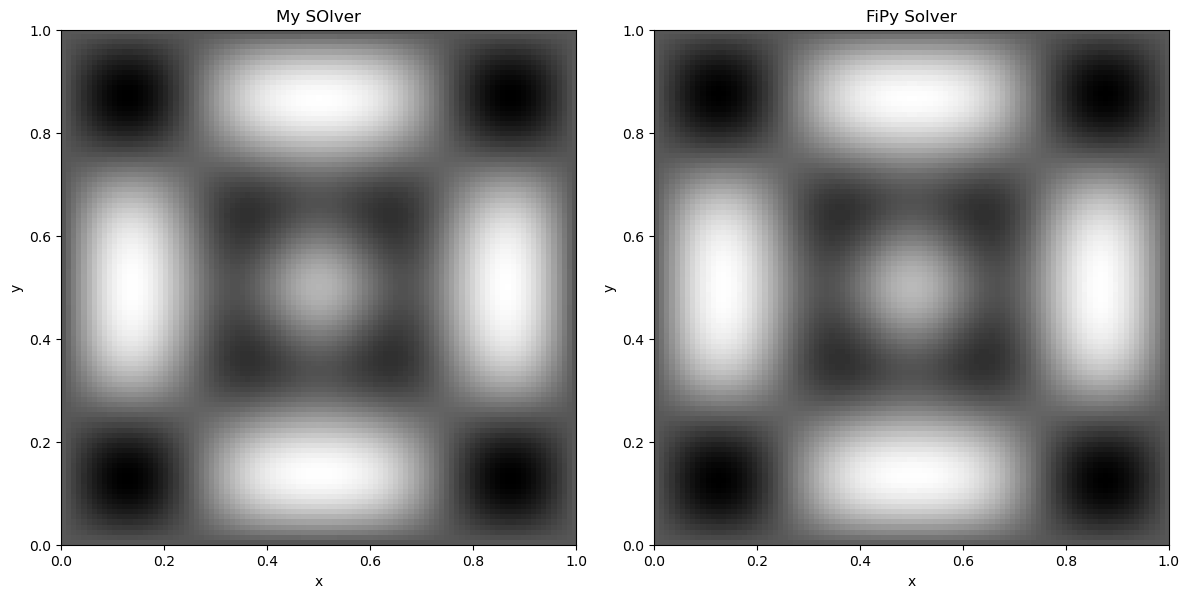

In [10]:
#Convert to image data 
offset = U.min() if U.min() < 0 else 0
U_i = U - offset
U_i = (U_i - np.min(U_i)) / (np.max(U_i) - np.min(U_i))
U_i = (U_i * 255).astype(np.uint8)

offset = Uf.min() if Uf.min() < 0 else 0
Uf_i = Uf - offset
Uf_i = (Uf_i - np.min(Uf_i)) / (np.max(Uf_i) - np.min(Uf_i))
Uf_i = (Uf_i * 255).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the initial condition
axs[0].imshow(U_i, cmap='gray', origin='lower', extent=(0, Lx, 0, Ly))
axs[0].set_title('My SOlver')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

# Plot the final condition
axs[1].imshow(Uf_i, cmap='gray', origin='lower', extent=(0, Lx, 0, Ly))
axs[1].set_title('FiPy Solver')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')


# Show the plot
plt.tight_layout()
plt.show()

In [3]:
#original image 
img = data.camera()
#img = data.coins()
#img = data.microaneurysms()

#noisy image
img_noise = img.copy()
for row in range(img.shape[0]):
    for col in range(img.shape[1]):
        if np.random.randint(100) == 1:
            img_noise[row,col] = np.random.randint(255)

#"cleaned" image
alpha = 1
t_end = 2
img_cln = image_diff_an(img_noise, t_end = t_end)


# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Noisy")
plt.imshow(img_noise, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Cleaned")
plt.imshow(img_cln, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for ^: 'int' and 'float'